<a href="https://colab.research.google.com/github/HARSH2028-HACKER/fogsafe/blob/main/Train_YOLO_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Train YOLO Models in Google Colab




**Verify NVIDIA GPU Availability**


In [ ]:
!nvidia-smi

Sat Sep 19 11:47:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# 2.&nbsp;Upload Image Dataset and Prepare Training Data

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

!cp "/content/gdrive/MyDrive/datasetfog safe/3/FOGSAFE_500.zip"  /content

Mounted at /content/gdrive


In [2]:
# To use my one of pre-made dataset instead of your own custom dataset, download it here (control which dataset is downloaded by commenting out either line)
!wget -O /content/data.zip https://s3.us-west-1.amazonaws.com/evanjuras.com/resources/candy_data_06JAN25.zip # Candy dataset
#!wget -O /content/data.zip https://s3.us-west-1.amazonaws.com/evanjuras.com/resources/YOLO_coin_data_12DEC30.zip # Coin dataset

--2026-09-28 10:04:28--  https://s3.us-west-1.amazonaws.com/evanjuras.com/resources/candy_data_06JAN25.zip
Resolving s3.us-west-1.amazonaws.com (s3.us-west-1.amazonaws.com)... 52.219.193.88, 16.15.4.23, 16.15.0.167, ...
Connecting to s3.us-west-1.amazonaws.com (s3.us-west-1.amazonaws.com)|52.219.193.88|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45172966 (43M) [application/zip]
Saving to: ‘/content/data.zip’

/content/data.zip   100%[===================>]  43.08M  70.6MB/s    in 0.6s    

2026-09-28 10:04:28 (70.6 MB/s) - ‘/content/data.zip’ saved [45172966/45172966]



## 2.2 Split images into train and validation folders

In [3]:
# Unzip images to a custom data folder
!unzip -q /content/FOGSAFE_500.zip -d /content/custom_data

In [4]:
!wget -O /content/train_val_split.py https://raw.githubusercontent.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/refs/heads/main/utils/train_val_split.py

# TO DO: Improve robustness of train_val_split.py script so it can handle nested data folders, etc
!python train_val_split.py --datapath="/content/custom_data/FOGSAFE_500" --train_pct=0.9

--2026-09-28 10:04:35--  https://raw.githubusercontent.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/refs/heads/main/utils/train_val_split.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3203 (3.1K) [text/plain]
Saving to: ‘/content/train_val_split.py’

/content/train_val_ 100%[===================>]   3.13K  --.-KB/s    in 0s      

2026-09-28 10:04:36 (40.2 MB/s) - ‘/content/train_val_split.py’ saved [3203/3203]

Created folder at /content/data/train/images.
Created folder at /content/data/train/labels.
Created folder at /content/data/validation/images.
Created folder at /content/data/validation/labels.
Number of image files: 500
Number of annotation files: 500
Images moving to train: 450
Images moving to validation: 50


# 3.&nbsp;Install Requirements (Ultralytics)

Next, we'll install the Ultralytics library in this Google Colab instance. This Python library will be used to train the YOLO model.

In [5]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 9.8 MB/s eta 0:00:00


# 4.&nbsp;Configure Training


In [6]:
# Python function to automatically create data.yaml config file

import yaml
import os

def create_data_yaml(path_to_classes_txt, path_to_data_yaml):

  # Read classes.txt
  if not os.path.exists(path_to_classes_txt):
    print(f'classes.txt file not found! Please check: {path_to_classes_txt}')
    return

  with open(path_to_classes_txt, 'r') as f:
    classes = []
    for line in f.readlines():
      if len(line.strip()) == 0:
        continue
      classes.append(line.strip())

  number_of_classes = len(classes)

  # Create data dictionary
  data = {
      'path': '/content/custom_data/FOGSAFE_500',
      'train': 'train/images',
      'val': 'validation/images',
      'nc': number_of_classes,
      'names': classes
  }

  # Write data.yaml
  with open(path_to_data_yaml, 'w') as f:
    yaml.dump(data, f, sort_keys=False)

  print(f'Created config file at {path_to_data_yaml}')

  return

# Paths
path_to_classes_txt = '/content/custom_data/FOGSAFE_500/classes.txt'
path_to_data_yaml = '/content/data.yaml'

create_data_yaml(path_to_classes_txt, path_to_data_yaml)

print('\nFile contents:\n')
!cat /content/data.yaml

Created config file at /content/data.yaml

File contents:

path: /content/custom_data/FOGSAFE_500
train: train/images
val: validation/images
nc: 5
names:
- person
- car
- bus
- truck
- other_vehicle


# 5.&nbsp;Train Model

## 5.2 Run Training!

Run the following code block to begin training. If you want to use a different model, number of epochs, or resolution, change `model`, `epochs`, or `imgsz`.

In [14]:
!yolo detect train data=/content/data.yaml model=yolo11s.pt epochs=40 imgsz=640

Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=None, opset=None, optimize=False, optimizer=auto, 

In [ ]:
!find /content -name "results.png" -type f

/content/runs/detect/train-3/results.png


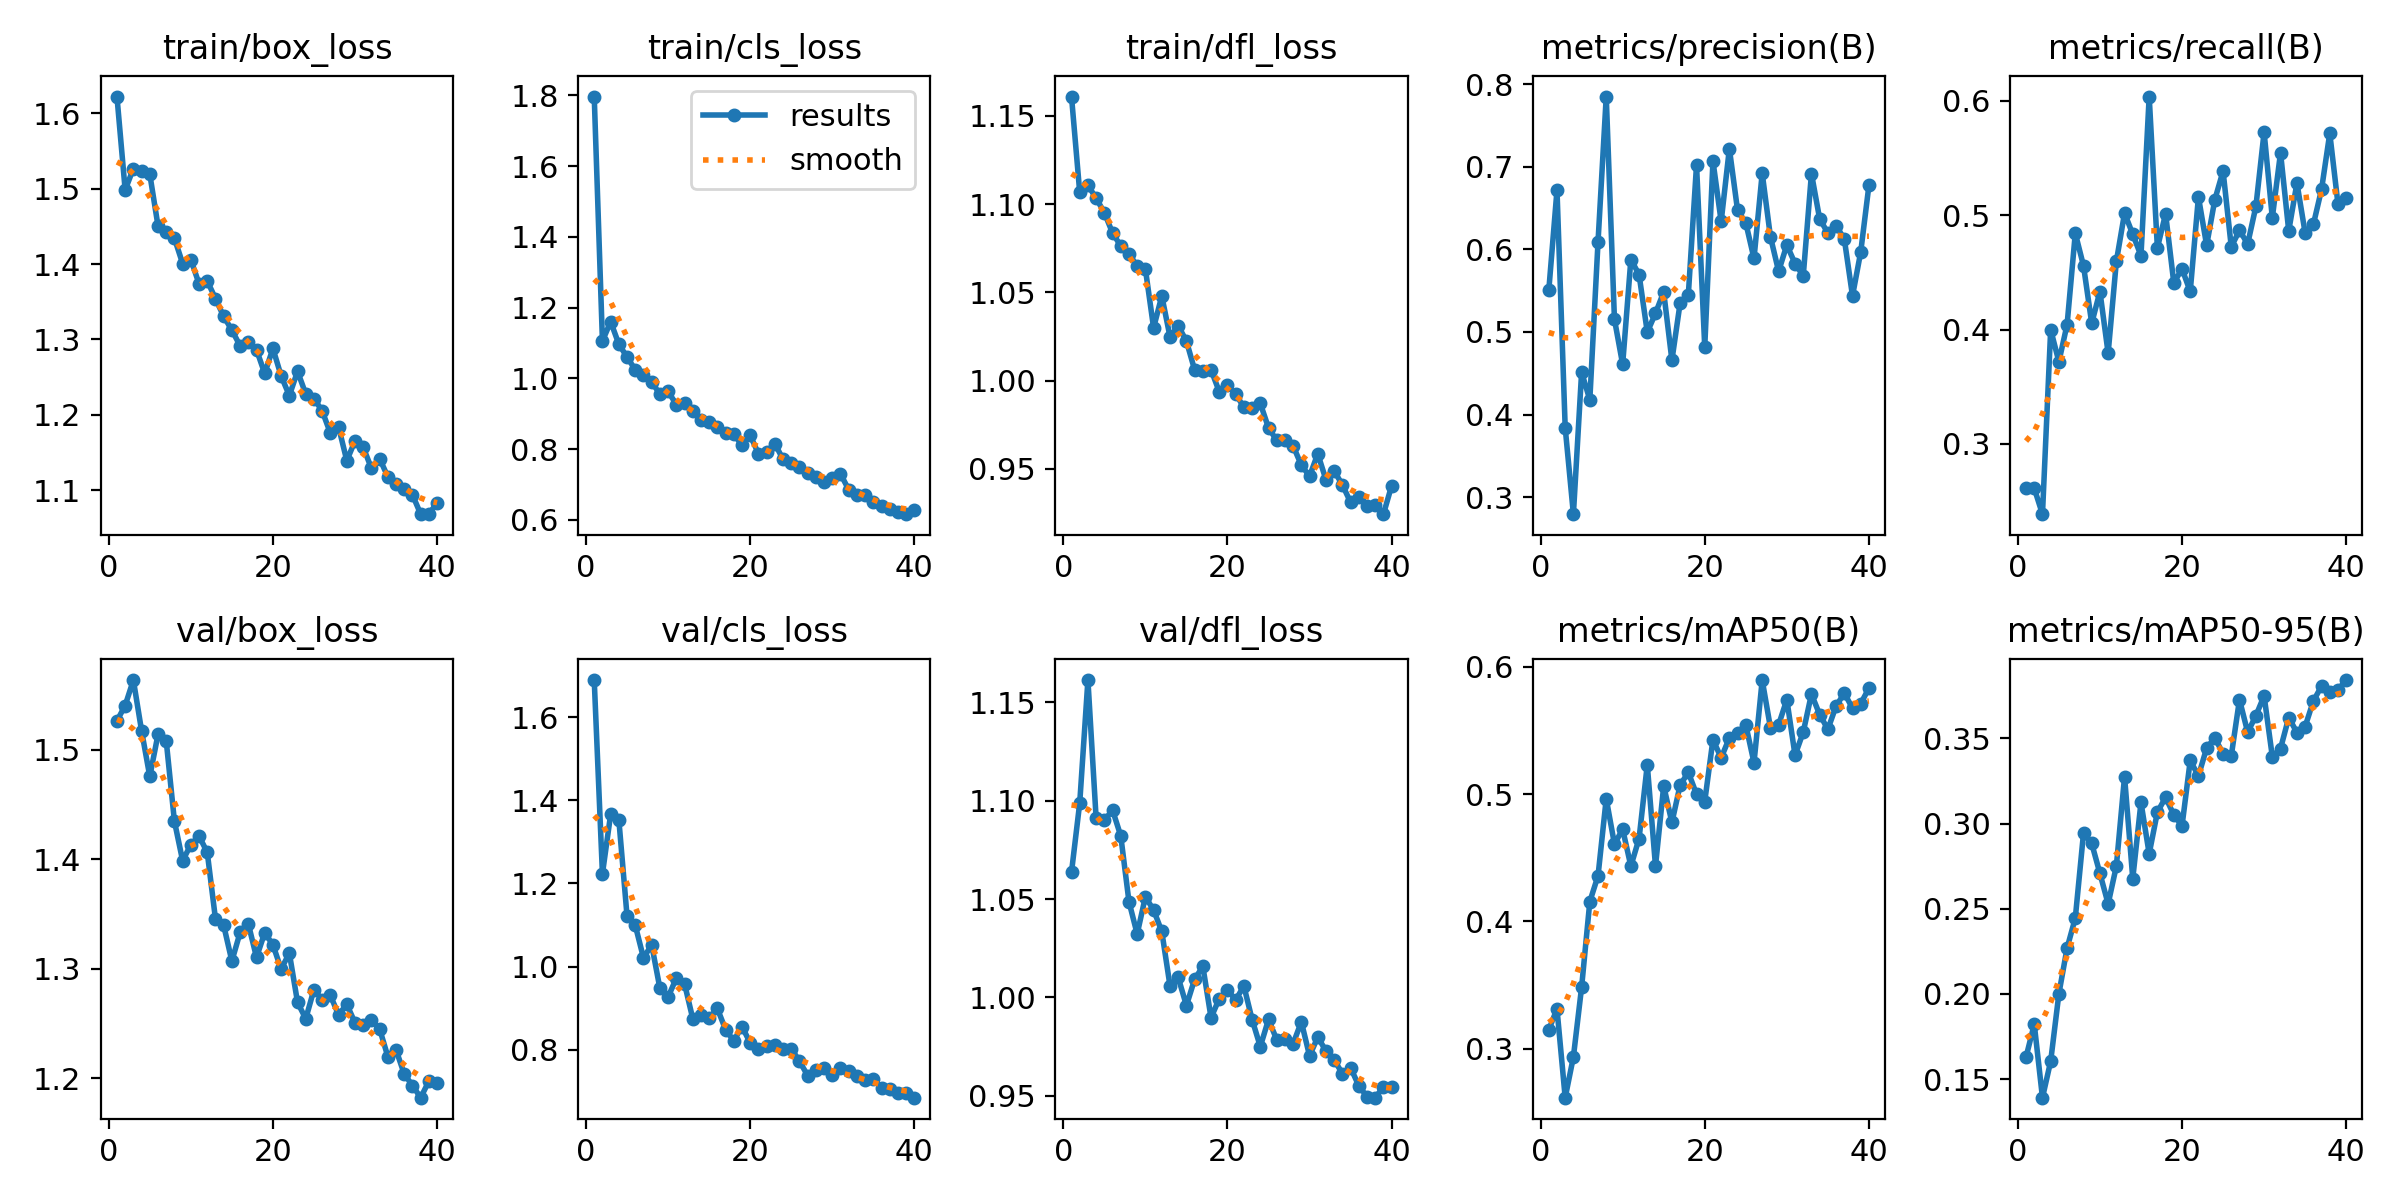

In [16]:
from IPython.display import Image, display
display(Image(filename="/content/runs/detect/train-3/results.png"))

In [9]:
!find /content/custom_data/FOGSAFE_500 -maxdepth 3 -type d

/content/custom_data/FOGSAFE_500
/content/custom_data/FOGSAFE_500/labels
/content/custom_data/FOGSAFE_500/images


In [10]:
!python /content/train_val_split.py --datapath="/content/custom_data/FOGSAFE_500" --train_pct=0.9

Number of image files: 500
Number of annotation files: 500
Images moving to train: 450
Images moving to validation: 50


In [11]:
!find /content/custom_data/FOGSAFE_500 -maxdepth 3 -type d

/content/custom_data/FOGSAFE_500
/content/custom_data/FOGSAFE_500/labels
/content/custom_data/FOGSAFE_500/images


In [12]:
from pathlib import Path
import random
import shutil

# Dataset
dataset = Path("/content/custom_data/FOGSAFE_500")
images_dir = dataset / "images"
labels_dir = dataset / "labels"

# Output folders
train_images = dataset / "train" / "images"
train_labels = dataset / "train" / "labels"
val_images = dataset / "validation" / "images"
val_labels = dataset / "validation" / "labels"

# Create folders
for folder in [train_images, train_labels, val_images, val_labels]:
    folder.mkdir(parents=True, exist_ok=True)

# Get images
images = list(images_dir.glob("*"))
random.seed(42)
random.shuffle(images)

# 90/10 split
train_images_list = images[:450]
val_images_list = images[450:]

# Copy files
for img in train_images_list:
    shutil.copy2(img, train_images / img.name)

    label = labels_dir / (img.stem + ".txt")
    if label.exists():
        shutil.copy2(label, train_labels / label.name)

for img in val_images_list:
    shutil.copy2(img, val_images / img.name)

    label = labels_dir / (img.stem + ".txt")
    if label.exists():
        shutil.copy2(label, val_labels / label.name)

print("Split complete!")
print("Training images:", len(list(train_images.glob("*"))))
print("Validation images:", len(list(val_images.glob("*"))))
print("Training labels:", len(list(train_labels.glob("*.txt"))))
print("Validation labels:", len(list(val_labels.glob("*.txt"))))

Split complete!
Training images: 450
Validation images: 50
Training labels: 450
Validation labels: 50


In [13]:
!find /content/custom_data/FOGSAFE_500 -maxdepth 2 -type f | head -30

/content/custom_data/FOGSAFE_500/classes.txt
/content/custom_data/FOGSAFE_500/notes.json
/content/custom_data/FOGSAFE_500/labels/video-BjSfmxLQqCGjg8tya-frame-000525-PtgfKeT9bndXjoeQ4.txt
/content/custom_data/FOGSAFE_500/labels/video-AEZAaF8epmvQv5Nfj-frame-015811-duQxgngtJGiKL4GGJ.txt
/content/custom_data/FOGSAFE_500/labels/video-vvYEi6EdCrYXeHwpD-frame-002448-5BfEbAYFCF3Y6YzxQ.txt
/content/custom_data/FOGSAFE_500/labels/video-fg5eBhFE7kHyXPtBi-frame-000389-ggdGFptYomWGLn3yH.txt
/content/custom_data/FOGSAFE_500/labels/video-DJYDQTZH7GLCqw3Tx-frame-004121-v2Cn4C83e3Fdd9Jzk.txt
/content/custom_data/FOGSAFE_500/labels/video-XNM8eHsvxCMJ6peuj-frame-000704-A74wzpHdxYma6XMjh.txt
/content/custom_data/FOGSAFE_500/labels/video-5v4MPkCMGEKPfroxc-frame-000587-DxgcAGbWD3nMbJB2J.txt
/content/custom_data/FOGSAFE_500/labels/video-WXTMrJkrK8BMoMkxk-frame-001999-NPkAYpXRGXqEyopeh.txt
/content/custom_data/FOGSAFE_500/labels/video-AEZAaF8epmvQv5Nfj-frame-006820-vxp6brJbyuj92d7sn.txt
/content/custom_data

#6.&nbsp;Test Model

In [21]:
!yolo detect predict model=runs/detect/train/weights/best.pt source=data/validation/images save=True

Traceback (most recent call last):
  File "/usr/local/bin/yolo", line 8, in <module>
    sys.exit(entrypoint())
             ~~~~~~~~~~^^
  File "/usr/local/lib/python3.13/dist-packages/ultralytics/cfg/__init__.py", line 1157, in entrypoint
    model = YOLO(model, task=task)
  File "/usr/local/lib/python3.13/dist-packages/ultralytics/models/yolo/model.py", line 84, in __init__
    super().__init__(model=model, task=task, verbose=verbose)
    ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/ultralytics/engine/model.py", line 135, in __init__
    self._load(model, task=task)
    ~~~~~~~~~~^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/ultralytics/engine/model.py", line 250, in _load
    self.model, self.ckpt = load_checkpoint(weights)
                            ~~~~~~~~~~~~~~~^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/ultralytics/nn/tasks.py", line 2007, in load_checkpoint
    ckpt, weight = torc

In [22]:
!find /content -name "best.pt" -type f

/content/runs/detect/train-3/weights/best.pt


In [24]:
!yolo detect predict model=/content/runs/detect/train-3/weights/best.pt source=/content/custom_data/FOGSAFE_500/validation/images save=True

Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 100 layers, 9,414,735 parameters, 0 gradients, 21.4 GFLOPs

image 1/50 /content/custom_data/FOGSAFE_500/validation/images/video-5YffDt2oYT6CDzYHk-frame-002627-WbSAEy3o9neMo748u.jpg: 512x640 8 persons, 3 cars, 12.5ms
image 2/50 /content/custom_data/FOGSAFE_500/validation/images/video-7EPybiwBrzjDKn7TZ-frame-004306-vpSh6EH97jLsrrQMG.jpg: 512x640 7 persons, 7 cars, 1 other_vehicle, 15.8ms
image 3/50 /content/custom_data/FOGSAFE_500/validation/images/video-7EPybiwBrzjDKn7TZ-frame-004321-f8G3sHB2bwCyF6z8t.jpg: 512x640 5 persons, 7 cars, 14.0ms
image 4/50 /content/custom_data/FOGSAFE_500/validation/images/video-7yaY3LisuPdNyfZH9-frame-003385-XSJ7NbnuvgijG95yH.jpg: 512x640 1 person, 2 cars, 12.4ms
image 5/50 /content/custom_data/FOGSAFE_500/validation/images/video-86XuF6pPvWfBCqyNt-frame-005435-YJJ6nyj5xkXTs4G5a.jpg: 512x640 1 person, 7 cars, 1 other_vehicle, 12.3ms
image 6/50 /content

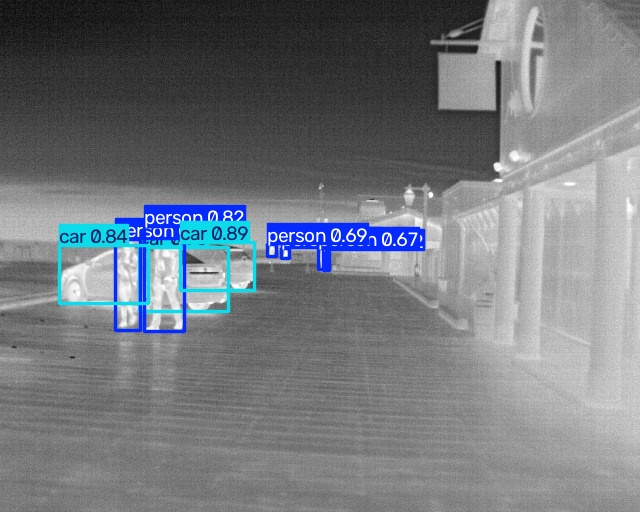

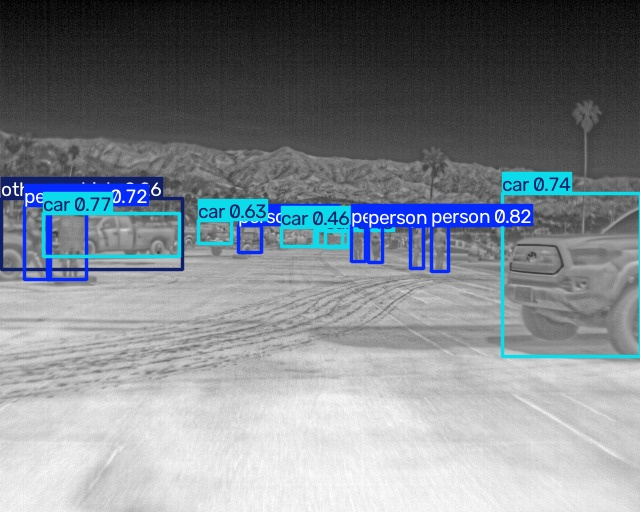

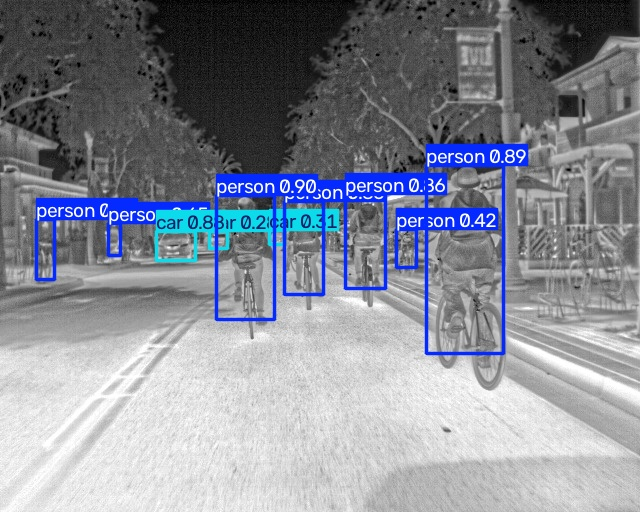

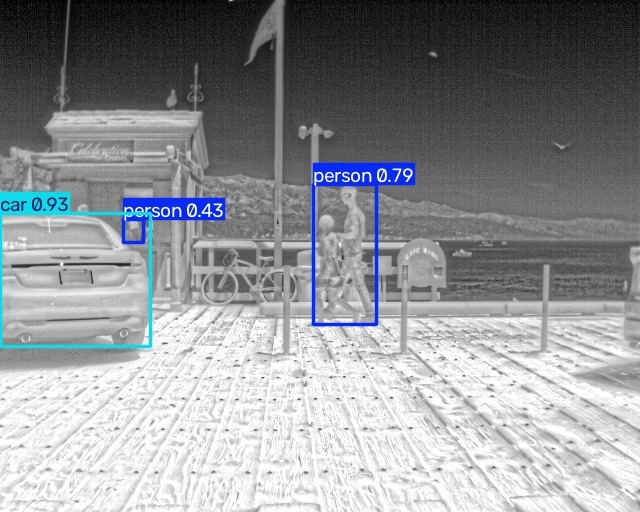

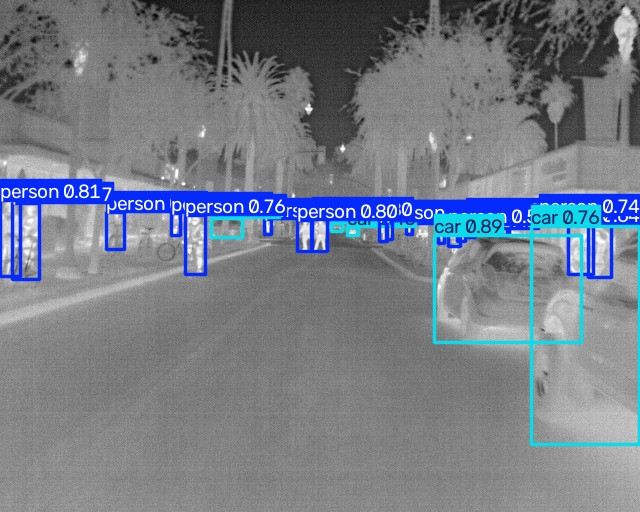

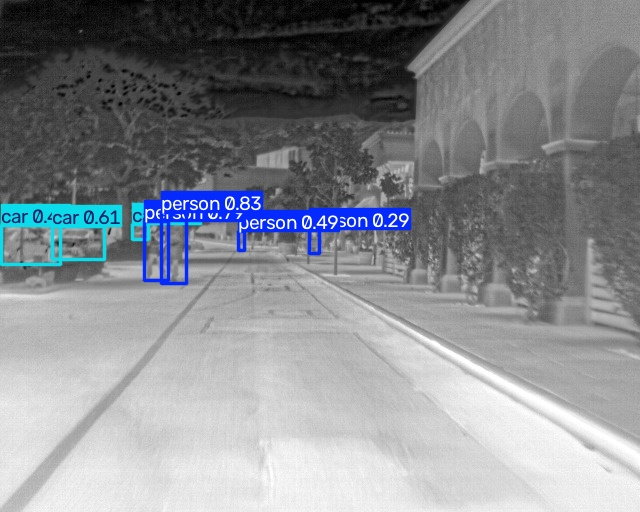

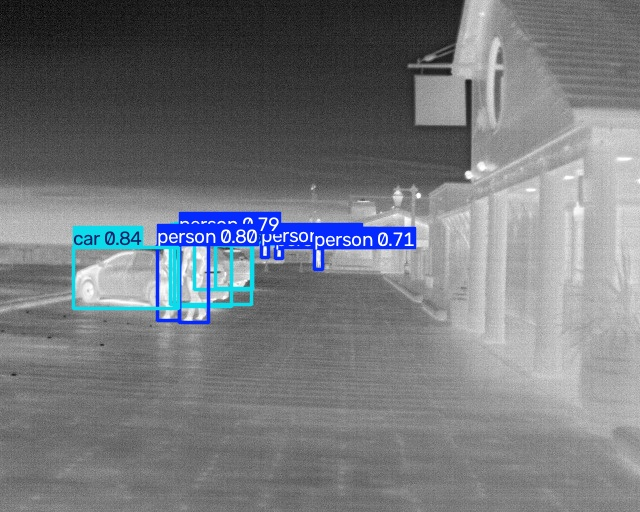

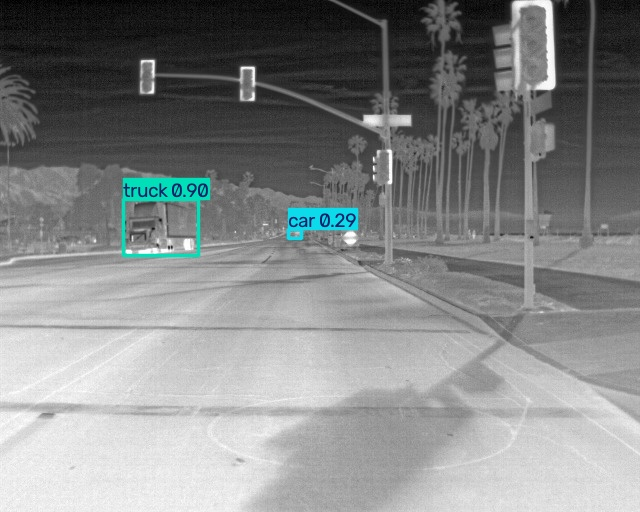

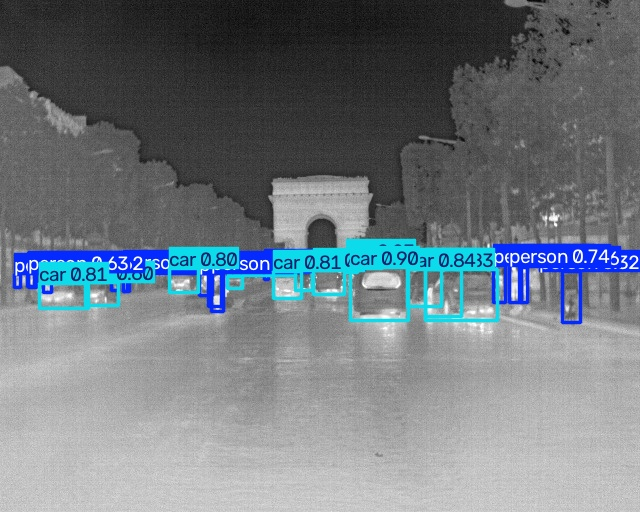

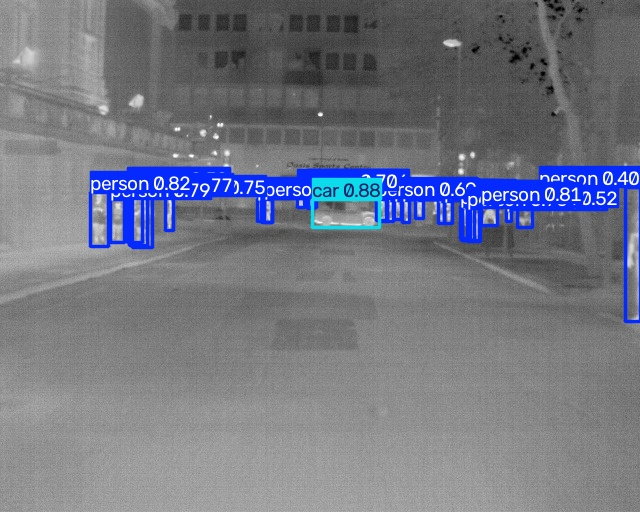

In [25]:
import glob
from IPython.display import Image, display

for image_path in glob.glob('/content/runs/detect/predict/*.jpg')[:10]:
    display(Image(filename=image_path, height=400))
    print('\n')

## 7.1 Download YOLO Model

First, zip and download the trained model by running the code blocks below.

The code creates a folder named `my_model`, moves the model weights into it, and renames them from `best.pt` to `my_model.pt`. It also adds the training results in case you want to reference them later. It then zips the folder as `my_model.zip`.

In [ ]:
# Create "my_model" folder to store model weights and training results
!mkdir -p /content/my_model

# Copy the best trained model
!cp /content/runs/detect/train-2/weights/best.pt /content/my_model/my_model.pt

# Copy the complete training results
!cp -r /content/runs/detect/train-2 /content/my_model/train

# Zip into "my_model.zip"
%cd /content/my_model
!zip /content/my_model.zip my_model.pt
!zip -r /content/my_model.zip train

%cd /content

/content/my_model
  adding: my_model.pt (deflated 8%)
updating: train/ (stored 0%)
updating: train/weights/ (stored 0%)
updating: train/args.yaml (deflated 53%)
  adding: train/train-2/ (stored 0%)
  adding: train/train-2/train_batch870.jpg (deflated 7%)
  adding: train/train-2/train_batch0.jpg (deflated 3%)
  adding: train/train-2/val_batch1_pred.jpg (deflated 7%)
  adding: train/train-2/val_batch1_labels.jpg (deflated 7%)
  adding: train/train-2/confusion_matrix.png (deflated 25%)
  adding: train/train-2/labels.jpg (deflated 37%)
  adding: train/train-2/confusion_matrix_normalized.png (deflated 21%)
  adding: train/train-2/train_batch2.jpg (deflated 2%)
  adding: train/train-2/results.csv (deflated 61%)
  adding: train/train-2/train_batch1.jpg (deflated 4%)
  adding: train/train-2/BoxPR_curve.png (deflated 11%)
  adding: train/train-2/weights/ (stored 0%)
  adding: train/train-2/weights/last.pt (deflated 8%)
  adding: train/train-2/weights/best.pt (deflated 8%)
  adding: train/train-

In [ ]:
!cp /content/my_model.zip "/content/gdrive/MyDrive/datasetfog safe/3/my_model.zip"

In [ ]:
# This takes forever for some reason, you can also just download the model from the sidebar
from google.colab import files

files.download('/content/my_model.zip')